In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/synthetic-financial-fraud-dataset/synthetic_fraud_dataset.csv


<div style="border-radius: 100px 0 100px 0px; border: 2px solid #f4f7f6ff; padding: 20px; background-color: #000000; text-align: center; box-shadow: 0px 2px 4px rgba(240, 234, 234, 0.48);width:95%;">
    <h1 style="color: red; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Import Required Libraries</h1>
</div>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score,KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score

from imblearn.over_sampling import SMOTE
from collections import Counter

from warnings import filterwarnings
filterwarnings("ignore")

<div style="border-radius: 100px 0 100px 0px; border: 2px solid #f4f7f6ff; padding: 20px; background-color: #000000; text-align: center; box-shadow: 0px 2px 4px rgba(240, 234, 234, 0.48);width:95%;">
    <h1 style="color: red; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Load Dataset</h1>
</div>

In [3]:
data = pd.read_csv('/kaggle/input/synthetic-financial-fraud-dataset/synthetic_fraud_dataset.csv')

<div style="border-radius: 100px 0 100px 0px; border: 2px solid #f4f7f6ff; padding: 20px; background-color: #000000; text-align: center; box-shadow: 0px 2px 4px rgba(240, 234, 234, 0.48);width:95%;">
    <h1 style="color: red; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">EDA</h1>
</div>

In [4]:
print("Train shape:", data.shape)

Train shape: (10000, 10)


In [5]:
data.head()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


In [6]:
data.tail()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
9995,1076,482,58.366442,POS,Clothing,DE,12,0.066366,0.086344,0
9996,4995,904,139.502160,POS,Travel,DE,13,0.119014,0.285680,0
9997,3485,527,71.012122,Online,Travel,TR,8,0.119204,0.262262,0
9998,7922,771,21.031405,QR,Grocery,UK,12,0.027088,0.295243,0
9999,6451,429,54.028632,ATM,Electronics,DE,11,0.096438,0.042823,0


In [7]:
print(data.isnull().sum())

transaction_id       0
user_id              0
amount               0
transaction_type     0
merchant_category    0
country              0
hour                 0
device_risk_score    0
ip_risk_score        0
is_fraud             0
dtype: int64


In [8]:
data.duplicated().sum().sum()

np.int64(0)

<div style="border-radius: 100px 0 100px 0px; border: 2px solid #f4f7f6ff; padding: 20px; background-color: #000000; text-align: center; box-shadow: 0px 2px 4px rgba(240, 234, 234, 0.48);width:95%;">
    <h1 style="color: red; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Data Info( )</h1>
</div>

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   amount             10000 non-null  float64
 3   transaction_type   10000 non-null  object 
 4   merchant_category  10000 non-null  object 
 5   country            10000 non-null  object 
 6   hour               10000 non-null  int64  
 7   device_risk_score  10000 non-null  float64
 8   ip_risk_score      10000 non-null  float64
 9   is_fraud           10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


<div style="border-radius: 100px 0 100px 0px; border: 2px solid #f4f7f6ff; padding: 20px; background-color: #000000; text-align: center; box-shadow: 0px 2px 4px rgba(240, 234, 234, 0.48);width:95%;">
    <h1 style="color: red; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Descriptive Statistic</h1>
</div>

In [10]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,10000.0,4999.500000,2886.895680,0.000000,2499.750000,4999.500000,7499.250000,9999.000000
user_id,10000.0,500.058700,288.328495,0.000000,247.000000,503.000000,750.250000,999.000000
amount,10000.0,178.142763,531.647950,1.000000,65.084753,101.686510,138.280872,11628.213881
hour,10000.0,14.247100,5.347383,0.000000,10.000000,14.000000,19.000000,23.000000
device_risk_score,10000.0,0.183773,0.177381,0.000030,0.075721,0.156583,0.234939,0.998737
ip_risk_score,10000.0,0.184669,0.175772,0.000009,0.077762,0.158290,0.236968,0.999603
is_fraud,10000.0,0.050000,0.217956,0.000000,0.000000,0.000000,0.000000,1.000000


<div style="border-radius: 100px 0 100px 0px; border: 2px solid #f4f7f6ff; padding: 20px; background-color: #000000; text-align: center; box-shadow: 0px 2px 4px rgba(240, 234, 234, 0.48);width:95%;">
    <h1 style="color: red; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Data Visualization</h1>
</div>

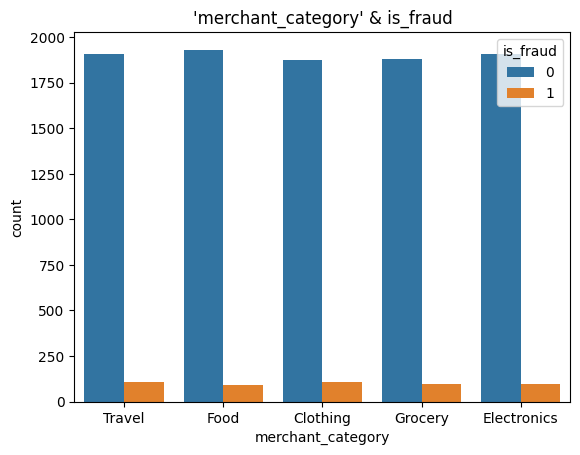

In [11]:
sns.countplot(x='merchant_category',hue="is_fraud",data=data)
plt.title("'merchant_category' & is_fraud")
plt.show()

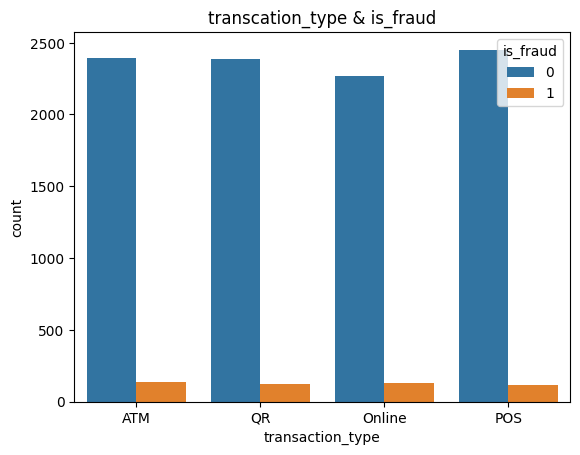

In [12]:
sns.countplot(x="transaction_type",hue="is_fraud",data=data)
plt.title("transcation_type & is_fraud")
plt.show()

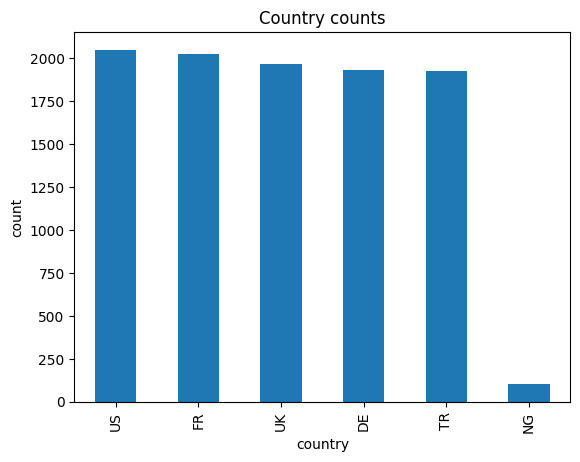

In [13]:
data["country"].value_counts().plot(kind="bar")
plt.title("Country counts")
plt.xlabel("country")
plt.ylabel("count")
plt.show()

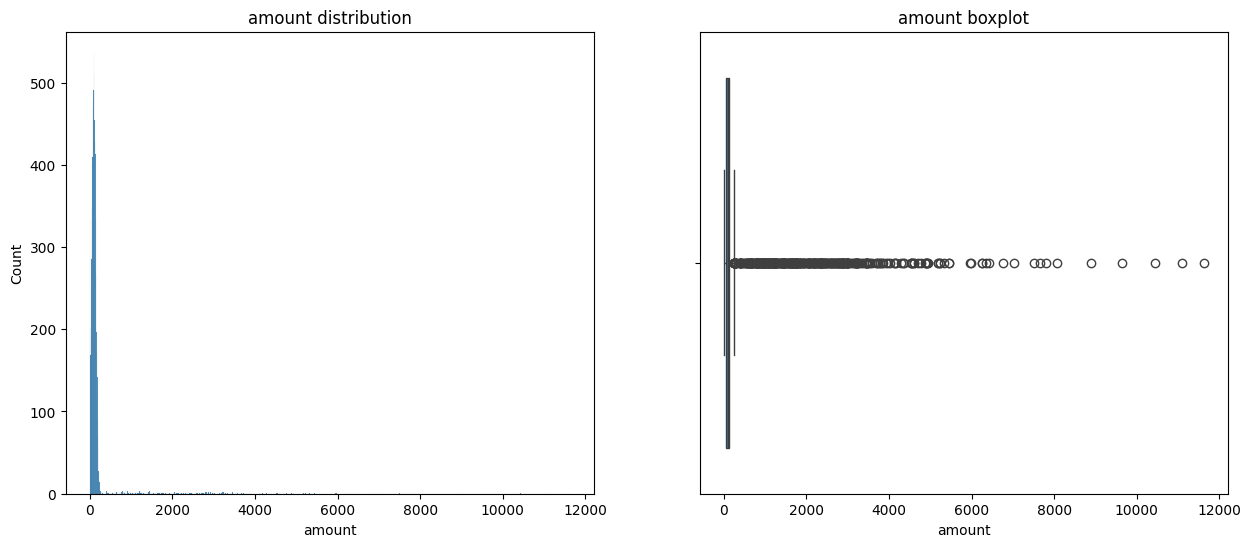

In [14]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
sns.histplot(x="amount",data=data)
plt.title("amount distribution")

plt.subplot(1,2,2)
sns.boxplot(x="amount",data=data)
plt.title("amount boxplot")
plt.show()

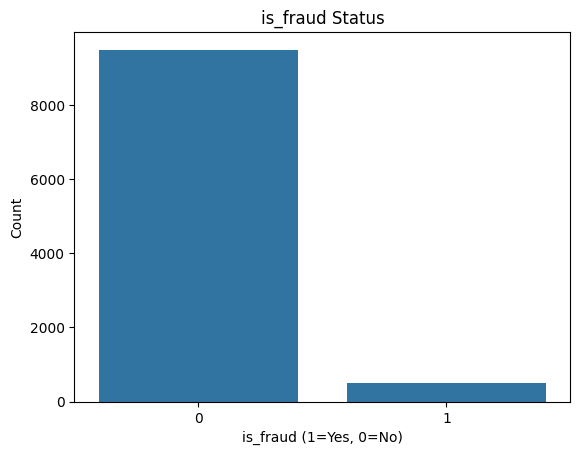

In [15]:
sns.countplot(x="is_fraud", data=data)
plt.title("is_fraud Status")
plt.xlabel("is_fraud (1=Yes, 0=No)")
plt.ylabel("Count")
plt.show()

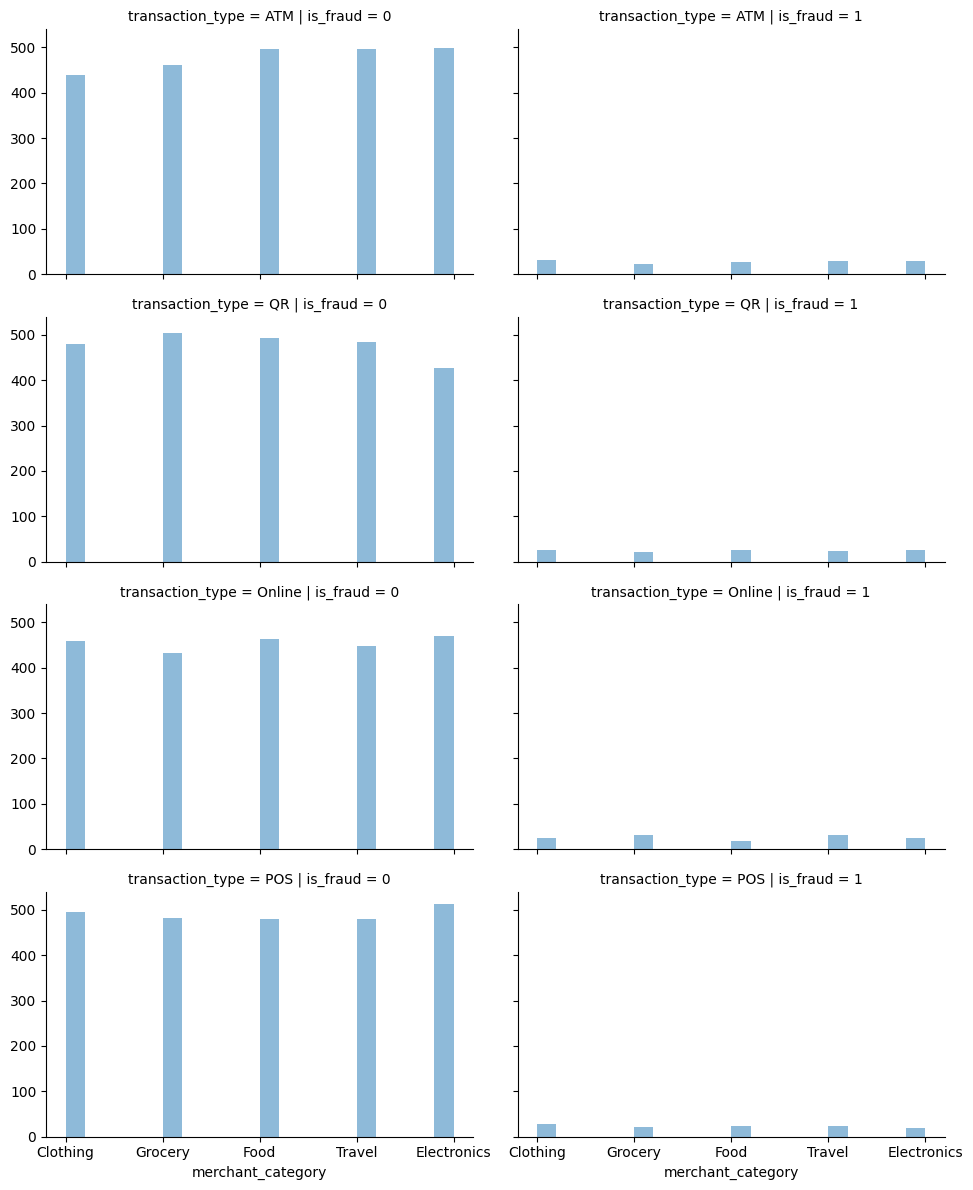

In [16]:
grid = sns.FacetGrid(data, col='is_fraud', row='transaction_type', aspect=1.6)
grid.map(plt.hist, 'merchant_category', alpha=.5, bins=20)
grid.add_legend()

<div style="border-radius: 100px 0 100px 0px; border: 2px solid #f4f7f6ff; padding: 20px; background-color: #000000; text-align: center; box-shadow: 0px 2px 4px rgba(240, 234, 234, 0.48);width:95%;">
    <h1 style="color: red; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Data Encoding</h1>
</div>

In [17]:
le = LabelEncoder()

obj_cols = data.select_dtypes(include='object').columns
for col in obj_cols:
    data[col]=le.fit_transform(data[[col]])


<div style="border-radius: 100px 0 100px 0px; border: 2px solid #f4f7f6ff; padding: 20px; background-color: #000000; text-align: center; box-shadow: 0px 2px 4px rgba(240, 234, 234, 0.48);width:95%;">
    <h1 style="color: red; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Feature Selection</h1>
</div>

In [18]:
x=data.drop("is_fraud",axis=1)

y=data["is_fraud"]

print(f"Original Class Distribution: {Counter(y)}")

Original Class Distribution: Counter({0: 9500, 1: 500})


<div style="border-radius: 100px 0 100px 0px; border: 2px solid #f4f7f6ff; padding: 20px; background-color: #000000; text-align: center; box-shadow: 0px 2px 4px rgba(240, 234, 234, 0.48);width:95%;">
    <h1 style="color: red; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Data Split</h1>
</div>

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

<div style="border-radius: 100px 0 100px 0px; border: 2px solid #f4f7f6ff; padding: 20px; background-color: #000000; text-align: center; box-shadow: 0px 2px 4px rgba(240, 234, 234, 0.48);width:95%;">
    <h1 style="color: red; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Balance Classes</h1>
</div>

In [20]:
smote = SMOTE(random_state=42)

x_train_balanced, y_train_balanced = smote.fit_resample(x_train, y_train)

# 5. Verify the results
print(f"Class Distribution after SMOTE: {Counter(y_train_balanced)}")

Class Distribution after SMOTE: Counter({0: 7600, 1: 7600})


<div style="border-radius: 100px 0 100px 0px; border: 2px solid #f4f7f6ff; padding: 20px; background-color: #000000; text-align: center; box-shadow: 0px 2px 4px rgba(240, 234, 234, 0.48);width:95%;">
    <h1 style="color: red; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Data Modeling</h1>
</div>

# Decision Tree

In [21]:
model=DecisionTreeClassifier(random_state=42)
model.fit(x_train_balanced,y_train_balanced)

y_pred1=model.predict(x_test)

print("accuracy_score: ",accuracy_score(y_test,y_pred1))
print("f1_score",f1_score(y_test,y_pred1))
print("confusion_matrix: \n",confusion_matrix(y_test,y_pred1))

accuracy_score:  1.0
f1_score 1.0
confusion_matrix: 
 [[1900    0]
 [   0  100]]


# Random Forest

In [22]:
rf=RandomForestClassifier(random_state=42,n_estimators=10,n_jobs=-2)
rf.fit(x_train_balanced,y_train_balanced)

y_pred2=rf.predict(x_test)

print("accuracy_score: ",accuracy_score(y_test,y_pred2))
print("f1_score",f1_score(y_test,y_pred2))
print("confusion_matrix:\n ",confusion_matrix(y_test,y_pred2))

accuracy_score:  1.0
f1_score 1.0
confusion_matrix:
  [[1900    0]
 [   0  100]]


# XGBRegressor

In [23]:
xgb = XGBClassifier(
	n_jobs=-2,
	random_state=42,
	n_estimators=100
)
xgb.fit(x_train_balanced,y_train_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-2, num_parallel_tree=None, ...)

In [24]:
y_pred3 = xgb.predict(x_test)

print("accuracy_score: ", accuracy_score(y_test, y_pred3))
print("f1_score", f1_score(y_test, y_pred3))
print("confusion_matrix: \n", confusion_matrix(y_test, y_pred3))

accuracy_score:  1.0
f1_score 1.0
confusion_matrix: 
 [[1900    0]
 [   0  100]]


---

# Note
The dataset is Generated from LLM and overly simple, which is why the model achieved perfect results. It doesn't require any feature engineering, preprocessing, or complex modeling — the patterns are artificially easy to learn.Because there is no pattern in this data

---

<div style="border-radius: 100px 0 100px 0px; border: 2px solid #f4f7f6ff; padding: 20px; background-color: #000000; text-align: center; box-shadow: 0px 2px 4px rgba(240, 234, 234, 0.48);width:95%;">
    <h1 style="color: red; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Cross Validation</h1>
</div>

In [25]:
dt=DecisionTreeClassifier(random_state=42)
cv_scores = cross_val_score(dt,x_train_balanced,y_train_balanced, cv=5, scoring='accuracy')

# Convert to positive accuracy
accuracy_scores = cv_scores

print(f"   🔹Accuracy = {np.mean(accuracy_scores):.4f} (std = {np.std(accuracy_scores):.4f})")
dt.fit(x_train_balanced,y_train_balanced)

   🔹Accuracy = 1.0000 (std = 0.0000)


DecisionTreeClassifier(random_state=42)

In [26]:
rf=RandomForestClassifier(random_state=42,n_estimators=10,n_jobs=-2)
cv_scores = cross_val_score(rf,x_train_balanced,y_train_balanced, cv=5, scoring='accuracy')

# Convert to positive accuracy
accuracy_scores = cv_scores

print(f"   🔹Accuracy= {np.mean(accuracy_scores):.4f} (std = {np.std(accuracy_scores):.4f})")
rf.fit(x_train_balanced,y_train_balanced)

   🔹Accuracy= 1.0000 (std = 0.0000)


RandomForestClassifier(n_estimators=10, n_jobs=-2, random_state=42)

In [27]:
xgb = XGBClassifier(
	n_jobs=-2,
	random_state=42,
	n_estimators=100
)

cv_scores = cross_val_score(xgb,x_train_balanced,y_train_balanced, cv=5, scoring='accuracy')

# Convert to positive accuracy
accuracy_scores = cv_scores

print(f"   🔹Accuracy = {np.mean(accuracy_scores):.4f} (std = {np.std(accuracy_scores):.4f})")
xgb.fit(x_train_balanced,y_train_balanced)

   🔹Accuracy = 1.0000 (std = 0.0000)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-2, num_parallel_tree=None, ...)

<div style="border-radius: 100px 0 100px 0px; border: 2px solid #f4f7f6ff; padding: 20px; background-color: #000000; text-align: center; box-shadow: 0px 2px 4px rgba(240, 234, 234, 0.48);width:95%;">
    <h1 style="color: red; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Correlation HeatMap</h1>
</div>

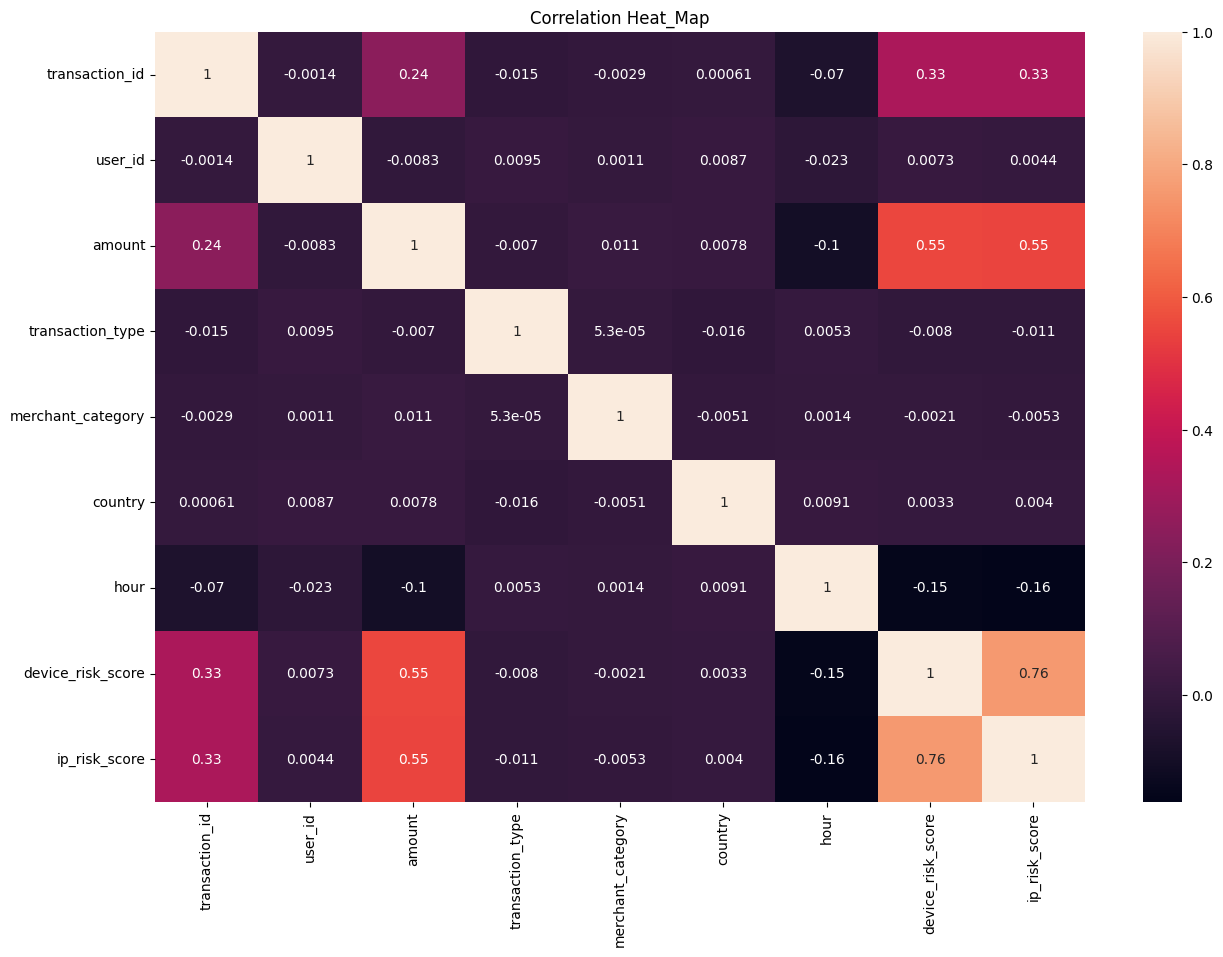

In [28]:
plt.figure(figsize=(15,10))
sns.heatmap(x.corr(),annot=True)
plt.title("Correlation Heat_Map")
plt.show()

<div style="border-radius: 100px 0 100px 0px; border: 2px solid #f4f7f6ff; padding: 20px; background-color: #000000; text-align: center; box-shadow: 0px 2px 4px rgba(240, 234, 234, 0.48);width:95%;">
    <h1 style="color: red; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Feature Importance</h1>
</div>

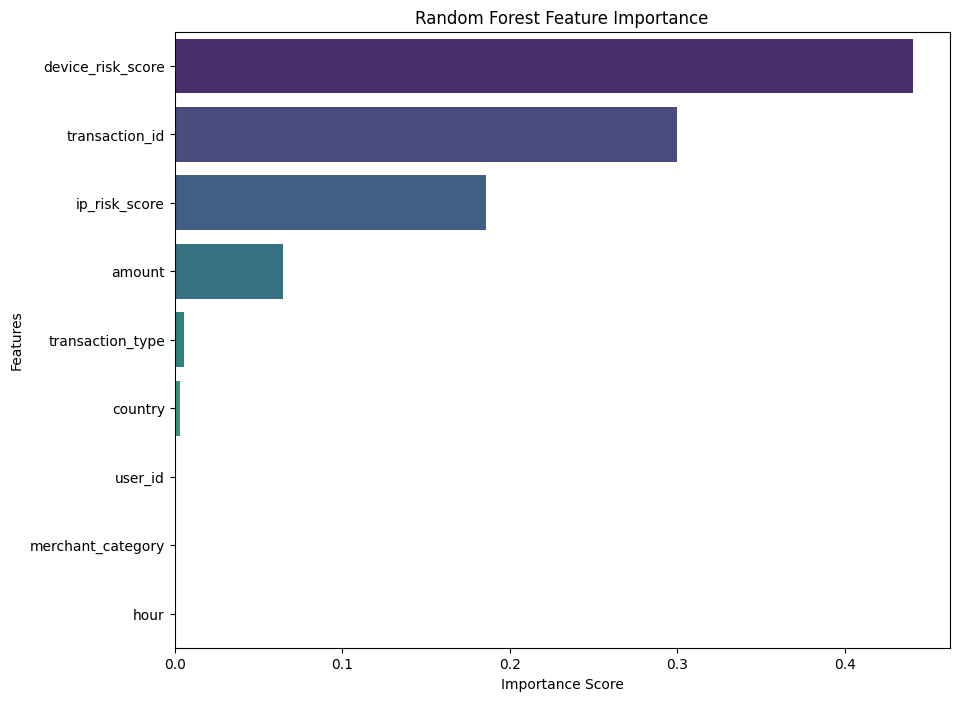

In [29]:
# Corrected Code
feat_importances = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_ 
})

# 3. Sort the DataFrame
feat_importances = feat_importances.sort_values(by='Importance', ascending=False)

# 4. Create the Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_importances, palette='viridis')

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Note
No pattern in this dataset<br>
Data was Ganerated Artificially <br><br>
Thank you for exploring this work!<br>
If you find it helpful, please consider upvoting it ❤️.<br>
Your support is greatly appreciated 🤩!

# Thanks!

<div style="border-radius: 100px 0 100px 0px; border: 2px solid #f4f7f6ff; padding: 20px; background-color: #000000; text-align: center; box-shadow: 0px 2px 4px rgba(240, 234, 234, 0.48);width:95%;">
    <h1 style="color: red; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">The End.......</h1>
</div>